# Inventory Policy Sensitivity

This notebook evaluates simple inventory scenarios on the final-test period. Safety buffers come from validation errors, so the test period remains an independent policy evaluation.

The simulation is controlled and hypothetical. It does not reproduce Walmart's replenishment system or recommend a production policy.


In [1]:
from collections import deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Assumptions

- inventory is reviewed daily
- lead times are fixed at 7, 14, 21, or 28 days
- unmet demand is treated as lost sales
- orders raise inventory position to future forecast demand plus a buffer
- no case packs, supplier limits, costs, or backorders are modeled


In [2]:
test_risk = pd.read_parquet(
    "data/processed/inventory_risk_daily.parquet"
)
empirical_buffers = pd.read_parquet(
    "data/processed/empirical_inventory_buffers.parquet"
)

BASELINE_LEAD_TIME = 14
POLICIES = ["none", "p90", "p95", "p98"]
LEAD_TIMES = [7, 14, 21, 28]

buffer_lookup = empirical_buffers.set_index(
    ["cat_id", "lead_time_days"]
)

print("Test rows:", len(test_risk))
empirical_buffers.round(1)


Test rows: 1095


,cat_id,lead_time_days,buffer_90,buffer_95,buffer_98,positive_windows
0,FOODS,7,21568.7,24436.8,28780.3,222
1,FOODS,14,33495.5,43549.8,49009.0,240
2,FOODS,21,44674.9,48933.5,54743.1,249
3,FOODS,28,51818.9,57081.2,59366.0,249
4,HOBBIES,7,1829.4,2076.9,2169.7,214
5,HOBBIES,14,2798.0,3278.1,3737.5,234
6,HOBBIES,21,3820.5,4477.9,5054.9,241
7,HOBBIES,28,4506.3,5590.1,6220.7,260
8,HOUSEHOLD,7,5864.9,6433.4,7425.6,272
9,HOUSEHOLD,14,8377.6,10086.9,12881.1,293


## Baseline Policy

Each day receives due orders, serves available demand, and orders enough to cover the next lead-time forecast plus safety stock.


In [3]:
def simulate_inventory(data, lead_time, safety_stock, demand_multiplier=1.0):
    data = data.sort_values("ds").reset_index(drop=True)
    forecasts = data["forecast"].to_numpy(float)
    demand = np.clip(data["actual"].to_numpy(float) * demand_multiplier, 0, None)

    pipeline = deque([0.0] * lead_time)
    on_order = 0.0
    on_hand = forecasts[:lead_time].sum() + safety_stock
    rows = []

    for day in range(len(data)):
        receipts = pipeline.popleft()
        on_order -= receipts
        available = on_hand + receipts

        fulfilled = min(available, demand[day])
        lost_units = demand[day] - fulfilled
        ending_inventory = available - fulfilled
        inventory_position = ending_inventory + on_order

        forecast_end = min(day + lead_time + 1, len(forecasts))
        future_forecast = forecasts[day + 1:forecast_end].sum()
        missing_days = lead_time - (forecast_end - day - 1)
        if missing_days > 0:
            future_forecast += missing_days * forecasts[-1]

        order_quantity = max(
            0.0,
            future_forecast + safety_stock - inventory_position,
        )
        pipeline.append(order_quantity)
        on_order += order_quantity
        on_hand = ending_inventory

        rows.append(
            {
                "ds": data.loc[day, "ds"],
                "actual_demand": demand[day],
                "receipts": receipts,
                "fulfilled_units": fulfilled,
                "lost_units": lost_units,
                "ending_inventory": ending_inventory,
                "order_quantity": order_quantity,
                "inventory_position": ending_inventory + on_order,
            }
        )

    result = pd.DataFrame(rows)
    assert (result["ending_inventory"] >= -1e-8).all()
    return result


In [4]:
def summarize_inventory(result):
    total_demand = result["actual_demand"].sum()
    total_lost = result["lost_units"].sum()

    return {
        "fill_rate": 1 - total_lost / total_demand,
        "stockout_days": int((result["lost_units"] > 0).sum()),
        "total_lost_units": total_lost,
        "avg_on_hand_inventory": result["ending_inventory"].mean(),
    }


baseline_buffer = buffer_lookup.loc[
    ("FOODS", BASELINE_LEAD_TIME), "buffer_95"
]
baseline = simulate_inventory(
    test_risk[test_risk["cat_id"] == "FOODS"],
    BASELINE_LEAD_TIME,
    baseline_buffer,
)

print(summarize_inventory(baseline))
baseline.head(10).round(1)


{'fill_rate': np.float64(0.9906559647870521), 'stockout_days': 25, 'total_lost_units': np.float64(90888.76708984375), 'avg_on_hand_inventory': np.float64(38622.09552520334)}


,ds,actual_demand,receipts,fulfilled_units,lost_units,ending_inventory,order_quantity,inventory_position
0,2015-06-21,27466.0,0.0,27466.0,0.0,357120.8,30018.9,387139.7
1,2015-06-22,22424.0,0.0,22424.0,0.0,334696.8,23842.4,388558.1
2,2015-06-23,21517.0,0.0,21517.0,0.0,313179.8,25934.1,392975.2
3,2015-06-24,20419.0,0.0,20419.0,0.0,292760.8,23423.4,395979.6
4,2015-06-25,21055.0,0.0,21055.0,0.0,271705.8,24478.1,399402.7
5,2015-06-26,23007.0,0.0,23007.0,0.0,248698.8,29565.8,405961.6
6,2015-06-27,26843.0,0.0,26843.0,0.0,221855.8,31547.1,410665.7
7,2015-06-28,27385.0,0.0,27385.0,0.0,194470.8,33389.0,416669.7
8,2015-06-29,21250.0,0.0,21250.0,0.0,173220.8,28993.4,424413.0
9,2015-06-30,20492.0,0.0,20492.0,0.0,152728.8,21880.3,425801.3


## Safety-Stock Scenarios


In [5]:
safety_rows = []

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    category_data = test_risk[test_risk["cat_id"] == category]

    for policy in POLICIES:
        safety_stock = 0.0 if policy == "none" else buffer_lookup.loc[
            (category, BASELINE_LEAD_TIME), f"buffer_{policy[1:]}"
        ]
        result = simulate_inventory(
            category_data,
            BASELINE_LEAD_TIME,
            safety_stock,
        )
        safety_rows.append(
            {
                "cat_id": category,
                "lead_time_days": BASELINE_LEAD_TIME,
                "policy": policy,
                "safety_stock": safety_stock,
                **summarize_inventory(result),
            }
        )

safety_results = pd.DataFrame(safety_rows)
safety_results.round(4)


,cat_id,lead_time_days,policy,safety_stock,fill_rate,stockout_days,total_lost_units,avg_on_hand_inventory
0,FOODS,14,none,0.0000,0.9430,166,554257.2871,12255.5777
1,FOODS,14,p90,33495.5257,0.9851,38,145184.0959,30486.0116
2,FOODS,14,p95,43549.8110,0.9907,25,90888.7671,38622.0955
3,FOODS,14,p98,49008.9622,0.9935,19,63593.0111,43153.9388
4,HOBBIES,14,none,0.0000,0.9336,214,95605.3114,1189.9203
5,HOBBIES,14,p90,2798.0177,0.9707,111,42170.6775,1969.2423
6,HOBBIES,14,p95,3278.1483,0.9755,94,35218.1396,2182.7003
7,HOBBIES,14,p98,3737.5022,0.9797,81,29185.6074,2410.6693
8,HOUSEHOLD,14,none,0.0000,0.9956,32,15626.4603,8126.3632
9,HOUSEHOLD,14,p90,8377.5621,1.0000,0,0.0000,15904.5542


## Lead-Time Scenarios


In [6]:
lead_time_rows = []

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    category_data = test_risk[test_risk["cat_id"] == category]

    for lead_time in LEAD_TIMES:
        for policy in POLICIES:
            safety_stock = 0.0 if policy == "none" else buffer_lookup.loc[
                (category, lead_time), f"buffer_{policy[1:]}"
            ]
            result = simulate_inventory(category_data, lead_time, safety_stock)
            lead_time_rows.append(
                {
                    "cat_id": category,
                    "lead_time_days": lead_time,
                    "policy": policy,
                    "safety_stock": safety_stock,
                    **summarize_inventory(result),
                }
            )

lead_time_results = pd.DataFrame(lead_time_rows)
lead_time_results[lead_time_results["policy"] == "p95"].round(4)


,cat_id,lead_time_days,policy,safety_stock,fill_rate,stockout_days,total_lost_units,avg_on_hand_inventory
2,FOODS,7,p95,24436.7528,0.9922,26,75672.1833,19805.9690
6,FOODS,14,p95,43549.8110,0.9907,25,90888.7671,38622.0955
10,FOODS,21,p95,48933.4676,0.9868,39,128392.3496,49864.4658
14,FOODS,28,p95,57081.1836,0.9876,55,121005.0469,66282.5705
18,HOBBIES,7,p95,2076.8936,0.9795,96,29569.8099,1158.4470
22,HOBBIES,14,p95,3278.1483,0.9755,94,35218.1396,2182.7003
26,HOBBIES,21,p95,4477.8802,0.9743,104,36945.0622,3675.1371
30,HOBBIES,28,p95,5590.0993,0.9727,106,39221.7114,5706.5849
34,HOUSEHOLD,7,p95,6433.3675,0.9998,3,871.3458,9632.4522
38,HOUSEHOLD,14,p95,10086.9129,1.0000,0,0.0000,17613.9050


## Demand Stress


In [7]:
stress_rows = []

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    category_data = test_risk[test_risk["cat_id"] == category]

    for factor in [0.8, 0.9, 1.0, 1.1, 1.2]:
        for policy in ["none", "p95"]:
            safety_stock = 0.0 if policy == "none" else buffer_lookup.loc[
                (category, BASELINE_LEAD_TIME), "buffer_95"
            ]
            result = simulate_inventory(
                category_data,
                BASELINE_LEAD_TIME,
                safety_stock,
                demand_multiplier=factor,
            )
            stress_rows.append(
                {
                    "cat_id": category,
                    "demand_multiplier": factor,
                    "policy": policy,
                    **summarize_inventory(result),
                }
            )

stress_results = pd.DataFrame(stress_rows)
stress_results.round(4)


,cat_id,demand_multiplier,policy,fill_rate,stockout_days,total_lost_units,avg_on_hand_inventory
0,FOODS,0.8,none,1.0000,0,0.000000e+00,65329.6442
1,FOODS,0.8,p95,1.0000,0,0.000000e+00,108879.4552
2,FOODS,0.9,none,0.9879,26,1.060107e+05,32185.4162
3,FOODS,0.9,p95,1.0000,0,0.000000e+00,72340.4569
4,FOODS,1.0,none,0.9430,166,5.542573e+05,12255.5777
5,FOODS,1.0,p95,0.9907,25,9.088877e+04,38622.0955
6,FOODS,1.1,none,0.8686,263,1.406366e+06,7807.8821
7,FOODS,1.1,p95,0.9580,129,4.498162e+05,15303.5758
8,FOODS,1.2,none,0.7994,300,2.341742e+06,6318.6770
9,FOODS,1.2,p95,0.8905,257,1.278396e+06,9825.5942


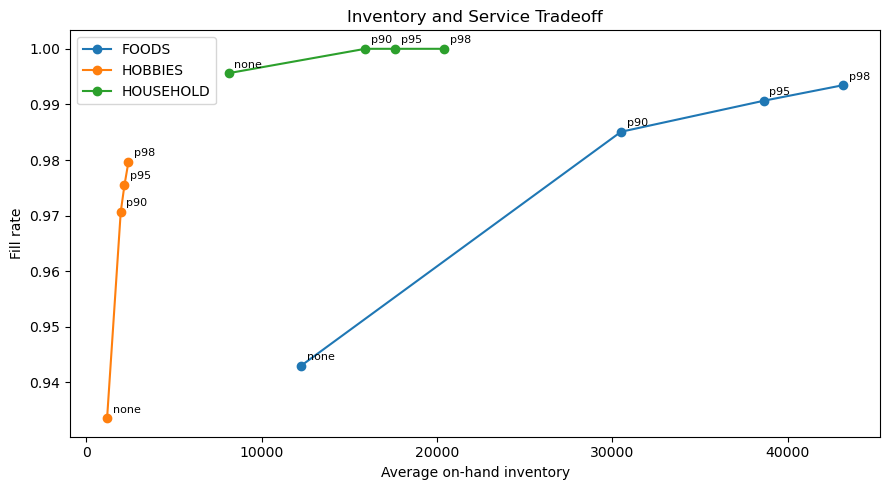

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    plot_data = safety_results[safety_results["cat_id"] == category]
    ax.plot(
        plot_data["avg_on_hand_inventory"],
        plot_data["fill_rate"],
        marker="o",
        label=category,
    )
    for _, row in plot_data.iterrows():
        ax.annotate(
            row["policy"],
            (row["avg_on_hand_inventory"], row["fill_rate"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

ax.set_title("Inventory and Service Tradeoff")
ax.set_xlabel("Average on-hand inventory")
ax.set_ylabel("Fill rate")
ax.legend()
plt.tight_layout()
plt.show()


## Findings

- Validation-calibrated buffers improve test-period service for `FOODS` and `HOBBIES`.
- Larger buffers provide diminishing fill-rate gains while increasing average inventory.
- Longer hypothetical lead times require more inventory protection.
- `HOUSEHOLD` needs less protection in these scenarios because its selected forecast tends to over-predict demand.

These results are an independent historical test of a controlled policy, not a Walmart replenishment recommendation or cost optimization.


In [9]:
safety_results.to_parquet(
    "data/processed/inventory_policy_safety_results.parquet",
    index=False,
)
lead_time_results.to_parquet(
    "data/processed/inventory_policy_lead_time_results.parquet",
    index=False,
)
stress_results.to_parquet(
    "data/processed/inventory_policy_stress_results.parquet",
    index=False,
)

print("Saved safety-stock, lead-time, and demand-stress results.")


Saved safety-stock, lead-time, and demand-stress results.
